# Salary Prediction

Corresponding  with this notebook is a slide deck where you will need to update all the portions in red.  Completing the notebook will provide all the results needed for the slides.  **Correctly completing the slides is a required part of the project.**


## Table of Contents
- [Introduction](#intro)
- [Part I - Descriptive Statistics](#descriptive)
- [Part II - Regression](#regression)
- [Part III - Interpret Results](#interpret)


<a id='intro'></a>
### Introduction

Linear Regression is very commonly performed by data analysts and data scientists.  For this project, you will be working to understand the results of a Linear Regression model associated with salaries.  Your goal is to work through this notebook to understand what variables are related to salary, and how exactly they are related.

As a final check, review your work for completeness.

<a id='descriptive'></a>
#### Part I - Descriptive Statistics

To get started, let's import our libraries.

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
random.seed(0)

For each of the parts of question `1` notice links to [pandas documentation](https://pandas.pydata.org/) is provided to assist with answering the questions.  Though there are other ways you could solve the questions, the documentation is provided to assist you with one fast way to find the answer to each question.


`1.a)` Now, read in the `salary_data.csv` data. Store it in `df`. Read in the dataset and take a look at the top few rows here. **This question is completed for you**:

In [2]:
df = pd.read_csv('salary_data.csv')
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


`b)` Use the below cell to find the number of rows in the dataset. [Helpful pandas link - `Dataframe.shape`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shape.html#pandas.DataFrame.shape)

In [3]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 375
Number of columns: 6


`c)` Do any of the rows have missing values? [Helpful Pandas Link One](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html) and [Helpful Pandas Link Two](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sum.html)  

If there are missing values, determine a method for dealing with them.

In [4]:
# Check for missing values in each column
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Show rows with missing data
print("\nRows with missing data:")
print(df[df.isnull().any(axis=1)])

Missing values per column:
Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

Total missing values: 12

Rows with missing data:
     Age Gender Education Level Job Title  Years of Experience  Salary
172  NaN    NaN             NaN       NaN                  NaN     NaN
260  NaN    NaN             NaN       NaN                  NaN     NaN


In [5]:
# Drop rows with missing values
print(f"Rows before cleaning: {df.shape[0]}")
df = df.dropna()
print(f"Rows after dropping NaN: {df.shape[0]}")

# Check for anomalous salary values
print(f"\nSmallest salaries:")
print(df.nsmallest(5, 'Salary')[['Age', 'Gender', 'Years of Experience', 'Salary']])

# Remove the anomalous $350 salary (likely a data entry error)
df = df[df['Salary'] >= 1000]
print(f"\nRows after removing anomaly: {df.shape[0]}")

Rows before cleaning: 375
Rows after dropping NaN: 373

Smallest salaries:
      Age  Gender  Years of Experience   Salary
259  29.0    Male                  1.5    350.0
82   25.0    Male                  0.0  30000.0
18   25.0  Female                  0.0  35000.0
49   25.0    Male                  0.0  35000.0
64   26.0    Male                  1.0  35000.0

Rows after removing anomaly: 372


`d)` How many employees are in each `Education Level`? Build a bar chart to show the count of employees in each level.

In [6]:
# Count employees by Education Level
education_counts = df['Education Level'].value_counts()
print("Employees per Education Level:")
print(education_counts)

Employees per Education Level:
Education Level
Bachelor's    223
Master's       98
PhD            51
Name: count, dtype: int64


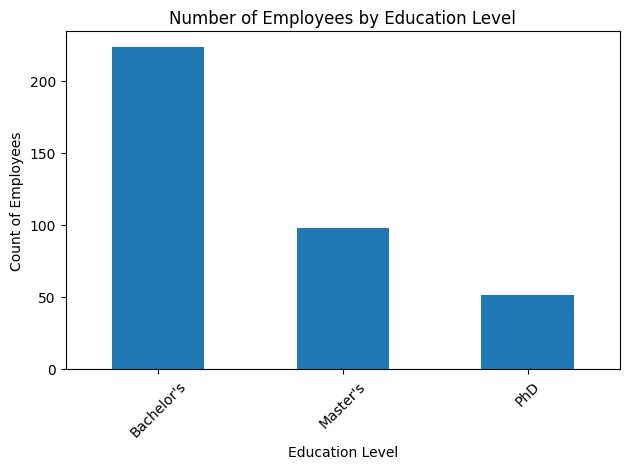

In [7]:
# Bar chart of results
df['Education Level'].value_counts().plot(kind='bar');
plt.title('Number of Employees by Education Level');
plt.ylabel('Count of Employees');
plt.xlabel('Education Level');
plt.xticks(rotation=45);
plt.tight_layout();
plt.show();

`e)` What are the possible values for `Salary`?  What does the distribution of `Salary` look like?

In [8]:
# Salary statistics
print("Salary Statistics:")
print(df['Salary'].describe())
print(f"\nSalary Range: ${df['Salary'].min():,.0f} to ${df['Salary'].max():,.0f}")

Salary Statistics:
count       372.000000
mean     100846.774194
std       48023.137565
min       30000.000000
25%       55000.000000
50%       95000.000000
75%      140000.000000
max      250000.000000
Name: Salary, dtype: float64

Salary Range: $30,000 to $250,000


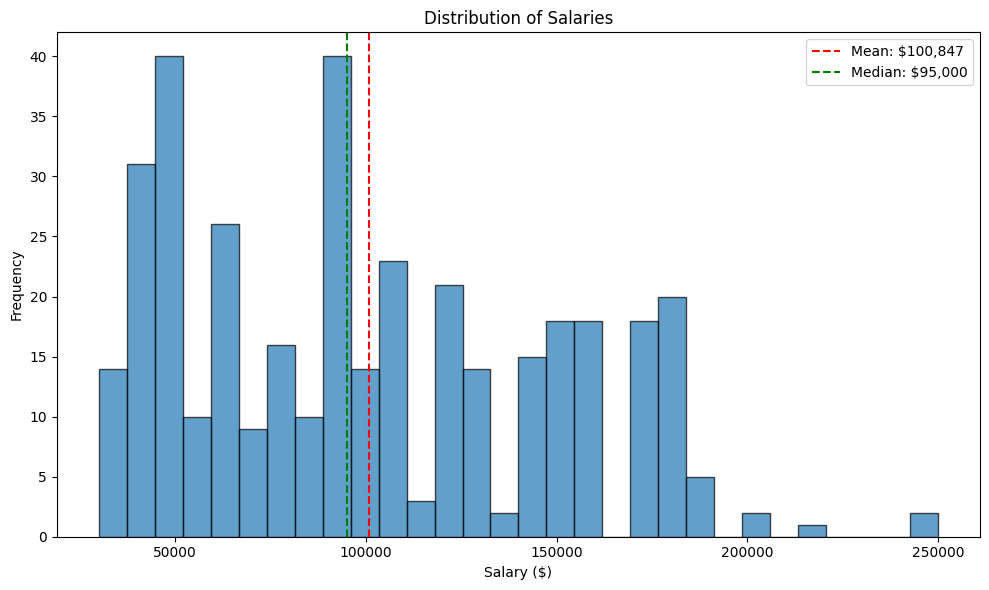

In [9]:
# Histogram of salary distribution
plt.figure(figsize=(10, 6))
plt.hist(df['Salary'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Salaries')
plt.xlabel('Salary ($)')
plt.ylabel('Frequency')
plt.axvline(df['Salary'].mean(), color='red', linestyle='--', label=f"Mean: ${df['Salary'].mean():,.0f}")
plt.axvline(df['Salary'].median(), color='green', linestyle='--', label=f"Median: ${df['Salary'].median():,.0f}")
plt.legend()
plt.tight_layout()
plt.show()

<a id='regression'></a>
#### Part II - Regression

`1.` Now that you have had a chance to learn more about the dataset, let's look more at how different factors are related to `Salary`.

`a)` Consider average salary by gender, is there evidence that salaries are higher for one gender over the other?

Salary by Gender:
                 mean    median  count
Gender                                
Female   97011.173184   90000.0    179
Male    104404.145078  100000.0    193

Male average salary: $104,404.15
Female average salary: $97,011.17
Difference: $7,392.97

Yes, there is evidence that males earn higher salaries on average than females in this dataset.


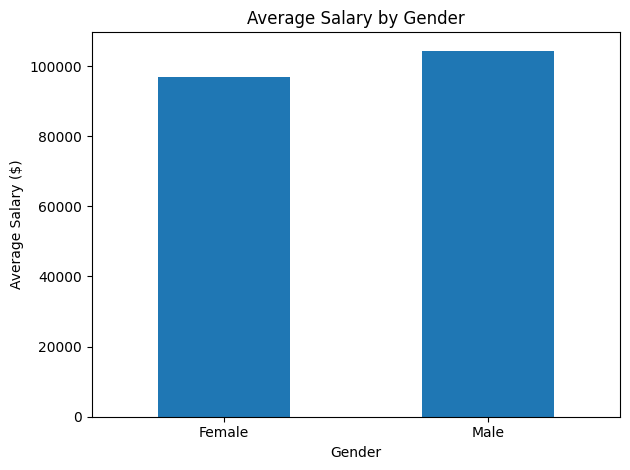

In [10]:
# Average salary by gender
gender_salary = df.groupby('Gender')['Salary'].agg(['mean', 'median', 'count'])
print("Salary by Gender:")
print(gender_salary)

print(f"\nMale average salary: ${df[df['Gender']=='Male']['Salary'].mean():,.2f}")
print(f"Female average salary: ${df[df['Gender']=='Female']['Salary'].mean():,.2f}")
print(f"Difference: ${df[df['Gender']=='Male']['Salary'].mean() - df[df['Gender']=='Female']['Salary'].mean():,.2f}")
print("\nYes, there is evidence that males earn higher salaries on average than females in this dataset.")

# Bar chart
df.groupby('Gender')['Salary'].mean().plot(kind='bar')
plt.title('Average Salary by Gender')
plt.ylabel('Average Salary ($)')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

`b)` Consider average salary by education level, is there evidence that salaries are higher for increased education?

Salary by Education Level:
                          mean    median  count
Education Level                                
Bachelor's        75089.686099   65000.0    223
Master's         129795.918367  120000.0     98
PhD              157843.137255  155000.0     51

Yes, there is strong evidence that higher education is associated with higher salaries.
PhD holders earn the most on average, followed by Master's, then Bachelor's.


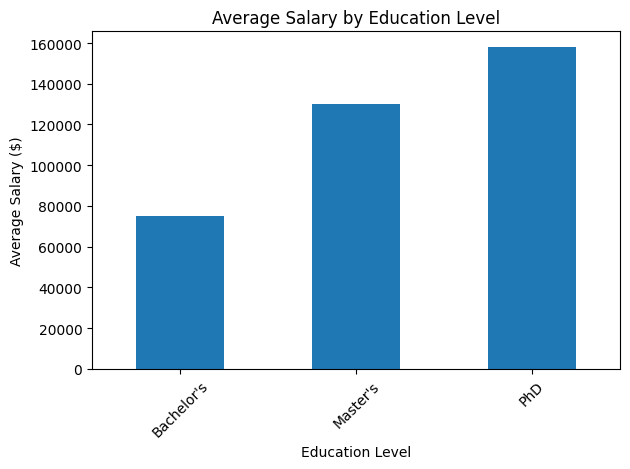

In [11]:
# Average salary by education level
education_salary = df.groupby('Education Level')['Salary'].agg(['mean', 'median', 'count'])
print("Salary by Education Level:")
print(education_salary)

print("\nYes, there is strong evidence that higher education is associated with higher salaries.")
print("PhD holders earn the most on average, followed by Master's, then Bachelor's.")

# Bar chart
df.groupby('Education Level')['Salary'].mean().plot(kind='bar')
plt.title('Average Salary by Education Level')
plt.ylabel('Average Salary ($)')
plt.xlabel('Education Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

`c)` Consider average salary by years of experience, is there evidence that salaries are associated with increased years of experience?

Correlation between Years of Experience and Salary: 0.9306

Yes, there is very strong evidence that salary is positively associated with years of experience.
The correlation coefficient of 0.9306 indicates a very strong positive linear relationship.


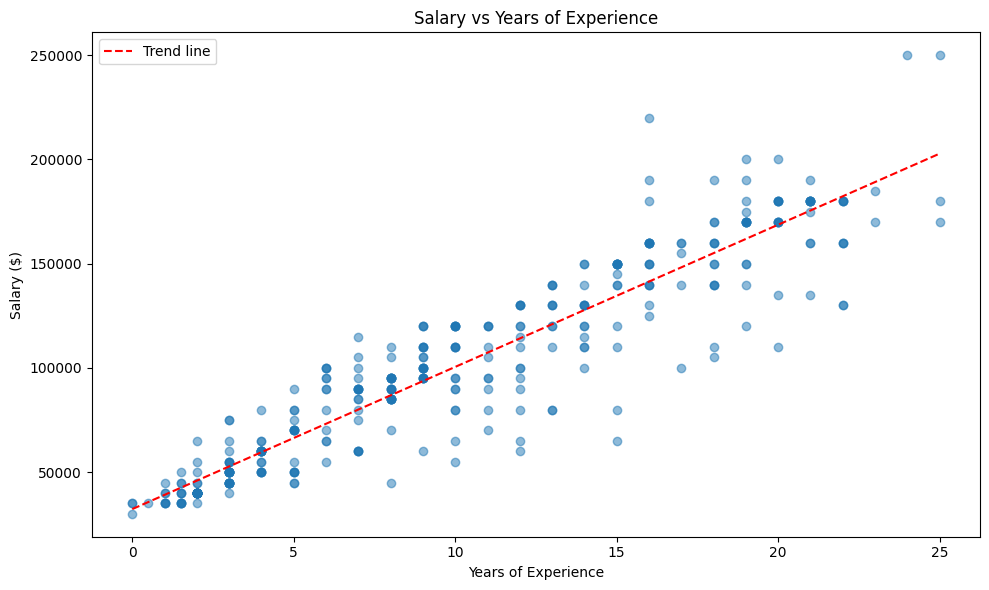

In [12]:
# Salary vs Years of Experience
correlation = df['Years of Experience'].corr(df['Salary'])
print(f"Correlation between Years of Experience and Salary: {correlation:.4f}")
print(f"\nYes, there is very strong evidence that salary is positively associated with years of experience.")
print(f"The correlation coefficient of {correlation:.4f} indicates a very strong positive linear relationship.")

# Scatter plot with trend line
plt.figure(figsize=(10, 6))
plt.scatter(df['Years of Experience'], df['Salary'], alpha=0.5)
z = np.polyfit(df['Years of Experience'], df['Salary'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Years of Experience'].min(), df['Years of Experience'].max(), 100)
plt.plot(x_line, p(x_line), "r--", label='Trend line')
plt.title('Salary vs Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary ($)')
plt.legend()
plt.tight_layout()
plt.show()

`d)`  To make use of Job Title column lets create bool flag based on word existiance


List of words:

* Director
* Junior
* Senior
* Manager
* Analyst
* Engineer

**This question is completed for you**

In [13]:
flag_words = ['director', 'junior', 'senior', 'manager', 'analyst', 'engineer']
df['Job Title'] = df['Job Title'].str.lower()

for word in flag_words:
    df['is_' + word] = df['Job Title'].str.contains(word)
    
df = df.drop('Job Title', axis=1)

`e)` Create a flag for gender where 1 is if a person is male and 0 if the person is not.

In [14]:
# Create binary flag for gender (1 = Male, 0 = Female)
df['is_male'] = (df['Gender'] == 'Male').astype(int)

# Drop the original Gender column
df = df.drop('Gender', axis=1)

print("Gender encoding verification:")
print(df['is_male'].value_counts())

Gender encoding verification:
is_male
1    193
0    179
Name: count, dtype: int64


`f)` Use statsmodels to fit a linear model to predict salary using each of the features from `a-e`.  These include:
* Gender
* Job TItle
* Years of Experience
* Education

In [15]:
import statsmodels.api as sm

# Create dummy variables for Education Level (Bachelor's is reference)
df = pd.get_dummies(df, columns=['Education Level'], drop_first=True, dtype=int)

# Convert boolean flag columns to int (from str.contains)
bool_cols = [col for col in df.columns if col.startswith('is_') and df[col].dtype == 'bool']
for col in bool_cols:
    df[col] = df[col].astype(int)

# Select features (exclude Age and Salary)
feature_cols = [col for col in df.columns if col not in ['Salary', 'Age']]
print("Features used in model:")
print(feature_cols)

X = df[feature_cols]
y = df['Salary']

# Add constant for intercept
X_const = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X_const).fit()
print(model.summary())

Features used in model:
['Years of Experience', 'is_director', 'is_junior', 'is_senior', 'is_manager', 'is_analyst', 'is_engineer', 'is_male', "Education Level_Master's", 'Education Level_PhD']
                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.917
Model:                            OLS   Adj. R-squared:                  0.914
Method:                 Least Squares   F-statistic:                     396.3
Date:                Sat, 14 Feb 2026   Prob (F-statistic):          7.55e-188
Time:                        01:16:37   Log-Likelihood:                -4075.5
No. Observations:                 372   AIC:                             8173.
Df Residuals:                     361   BIC:                             8216.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                

<a id='interpretation'></a>
### Part III - Interpret Results

`1.` Consider you are tasked with finding which features in your linear model are significantly related to salary.  Were there any features that were not significantly related to salary in your first model?  If not, remove those features and fit a new model.  Only keep the features that were significant from the original model.

In [16]:
# Identify significant features (p < 0.05)
print("P-values from full model:")
print(model.pvalues.sort_values())
print()

# Get significant features
significant = model.pvalues[model.pvalues < 0.05].index.tolist()
significant.remove('const')
not_significant = [f for f in feature_cols if f not in significant]

print(f"Significant features (p < 0.05): {significant}")
print(f"Not significant features: {not_significant}")

# Fit reduced model with only significant features
X_reduced = sm.add_constant(df[significant])
model_reduced = sm.OLS(y, X_reduced).fit()
print("\n" + "="*60)
print("REDUCED MODEL SUMMARY:")
print(model_reduced.summary())

P-values from full model:
Years of Experience         1.169459e-81
const                       5.152151e-32
Education Level_PhD         7.988056e-16
is_director                 1.795235e-12
is_senior                   1.026940e-10
Education Level_Master's    1.242091e-10
is_male                     4.595765e-07
is_manager                  2.074475e-02
is_junior                   8.854217e-02
is_engineer                 5.013086e-01
is_analyst                  8.459822e-01
dtype: float64

Significant features (p < 0.05): ['Years of Experience', 'is_director', 'is_senior', 'is_manager', 'is_male', "Education Level_Master's", 'Education Level_PhD']
Not significant features: ['is_junior', 'is_analyst', 'is_engineer']

REDUCED MODEL SUMMARY:
                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.914
Method:         

`a)` With each additional year of experience, what is the expected change in salary?  What is the 95% confidence interval of the change?

With each additional year of experience, salary is expected to increase by approximately **$5,081** (coefficient: $5,081.26). The 95% confidence interval for this change is **($4,737, $5,426)**. This means we are 95% confident that the true increase in salary per additional year of experience is between $4,737 and $5,426, holding all other variables constant. This is both statistically significant (p < 0.001) and practically meaningful — each year of experience corresponds to roughly a $5,000 raise.

`b)` What is the expected difference in salary between someone with a senior title and someone with none of the other title indications?

An employee with a senior title is expected to earn approximately **$14,346 more** (coefficient: $14,345.60) than someone without any of the title indications (director, senior, manager), holding all other factors constant. This effect is highly statistically significant (p < 0.001).

`c)` What is the expected difference in salary between someone with a PhD and an individual with no PhD nor master's degree?  What is the 95% confidence interval of the change?

An individual with a PhD is expected to earn approximately **$23,137 more** (coefficient: $23,137.04) than someone with a Bachelor's degree (the reference category), holding all other factors constant. The 95% confidence interval is **($17,772, $28,502)**, meaning we are 95% confident the true salary difference between PhD and Bachelor's holders falls within this range. This is both statistically significant (p < 0.001) and practically substantial.

`d)` If a male employee has 5 years of experience as a senior engineer with a bachelor's degree, what is the expected salary of the employee?

In [17]:
# Compute predicted salary for: male, 5 years experience, senior engineer, bachelor's degree
# Build prediction input matching reduced model features
pred_values = {col: 0 for col in model_reduced.params.index}
pred_values['const'] = 1
pred_values['Years of Experience'] = 5
pred_values['is_senior'] = 1
pred_values['is_male'] = 1
# Bachelor's is the reference category, so education dummies stay 0

pred_input = pd.DataFrame([pred_values])
predicted_salary = model_reduced.predict(pred_input)[0]
residual = 110000 - predicted_salary

print(f"Predicted salary: ${predicted_salary:,.2f}")
print(f"Residual (actual $110,000 - predicted): ${residual:,.2f}")

Predicted salary: $76,669.09
Residual (actual $110,000 - predicted): $33,330.91


Using the reduced model, the expected salary is calculated as:

Predicted Salary = $29,068 (intercept) + $5,081 x 5 (years of experience) + $14,346 (is_senior) + $7,849 (is_male) = **$76,669**

Note: The "engineer" flag was removed from the reduced model because it was not statistically significant (p = 0.501), so it does not factor into the prediction. Education Level for Bachelor's is the reference category (coefficient = 0).

`e)` Imagine that the employee in question `d)` actually has a salary of $110,000, what would the residual be for this employee?

The residual is the difference between the actual salary and the predicted salary:

Residual = Actual Salary - Predicted Salary = $110,000 - $76,669 = **$33,331**

The positive residual indicates that this employee earns $33,331 more than the model predicts, suggesting they are paid above what the model would expect given their characteristics.

`f)` How well do you think your model fits?  What metrics or plots would you consider to understand if this model does a good job of predicting salary?

R-squared: 0.9157
Adjusted R-squared: 0.9141
Mean Absolute Error: $9,533.23
Root Mean Squared Error: $13,923.62


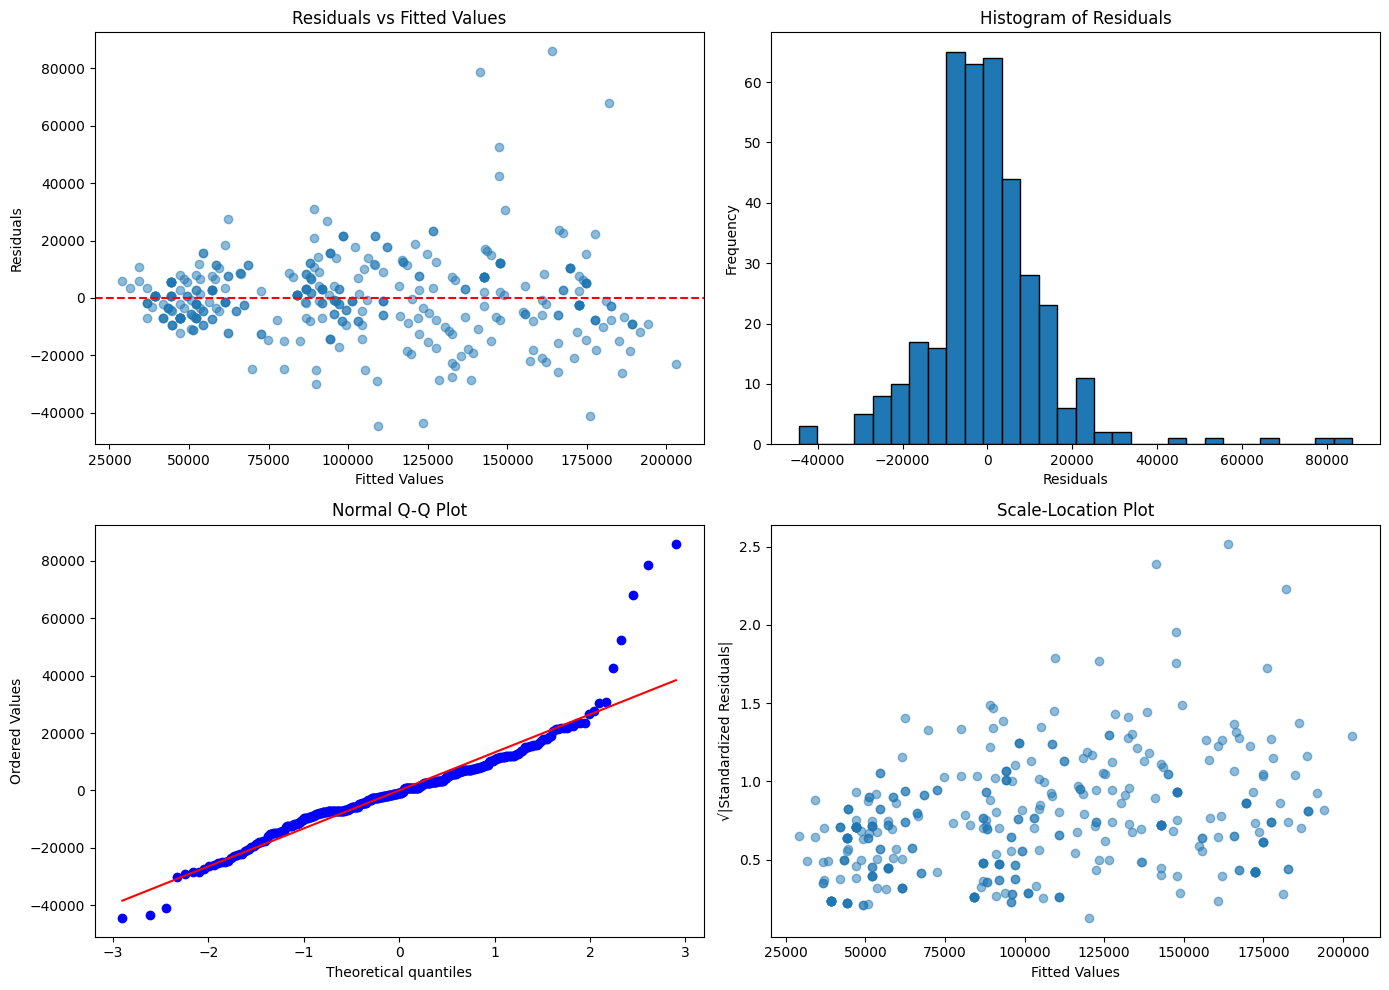

In [18]:
from scipy import stats

# Model fit metrics
print(f"R-squared: {model_reduced.rsquared:.4f}")
print(f"Adjusted R-squared: {model_reduced.rsquared_adj:.4f}")
print(f"Mean Absolute Error: ${np.mean(np.abs(model_reduced.resid)):,.2f}")
print(f"Root Mean Squared Error: ${np.sqrt(np.mean(model_reduced.resid**2)):,.2f}")

# Residual diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(model_reduced.fittedvalues, model_reduced.resid, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted Values')

# 2. Histogram of residuals
axes[0, 1].hist(model_reduced.resid, bins=30, edgecolor='black')
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Histogram of Residuals')

# 3. Q-Q Plot
stats.probplot(model_reduced.resid, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Normal Q-Q Plot')

# 4. Scale-Location Plot
standardized_resid = np.sqrt(np.abs(model_reduced.get_influence().resid_studentized_internal))
axes[1, 1].scatter(model_reduced.fittedvalues, standardized_resid, alpha=0.5)
axes[1, 1].set_xlabel('Fitted Values')
axes[1, 1].set_ylabel('√|Standardized Residuals|')
axes[1, 1].set_title('Scale-Location Plot')

plt.tight_layout()
plt.show()

The model demonstrates a strong fit to the data:

1. **R-squared (0.916)**: The model explains approximately 91.6% of the variance in salary, indicating strong explanatory power. The adjusted R-squared (0.914) is nearly identical, confirming that the features are not overfitting.

2. **Residual Analysis**:
   - The residuals vs. fitted values plot shows a roughly random scatter around zero, supporting the assumption of linearity.
   - The histogram of residuals shows a right skew, suggesting some departure from perfect normality.
   - The Q-Q plot confirms slight deviation from normality in the tails (heavy right tail), which is common with salary data.
   - The scale-location plot shows some increase in spread at higher fitted values, suggesting mild heteroscedasticity.

3. **Practical Significance**: The model captures the major drivers of salary — experience, title seniority, gender, and education level — which align with domain knowledge about salary determination.

4. **Limitations**: The non-normal residual distribution and potential heteroscedasticity suggest that confidence intervals and p-values should be interpreted with some caution. A log transformation of salary or robust standard errors could be considered for improvement.

<a id='finalcheck'></a>
## Final Check!

Congratulations!  You have reached the end of the salary prediction project!  You should be very proud of all you have accomplished!

> **Tip**: Once you are satisfied with your work here, check over your notebook to make sure the presentation is as polished as possible.


<a id='submission'></a>
## Submission

